## <small>
Copyright (c) 2017-21 Andrew Glassner

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
</small>



# Deep Learning: A Visual Approach
## by Andrew Glassner, https://glassner.com
### Order: https://nostarch.com/deep-learning-visual-approach
### GitHub: https://github.com/blueberrymusic
------

### What's in this notebook

This notebook is provided as a “behind-the-scenes” look at code used to make some of the figures in this chapter. It is cleaned up a bit from the original code that I hacked together, and is only lightly commented. I wrote the code to be easy to interpret and understand, even for those who are new to Python. I tried never to be clever or even more efficient at the cost of being harder to understand. The code is in Python3, using the versions of libraries as of April 2021.

This notebook may contain additional code to create models and images not in the book. That material is included here to demonstrate additional techniques.

Note that I've included the output cells in this saved notebook, but Jupyter doesn't save the variables or data that were used to generate them. To recreate any cell's output, evaluate all the cells from the start up to that cell. A convenient way to experiment is to first choose "Restart & Run All" from the Kernel menu, so that everything's been defined and is up to date. Then you can experiment using the variables, data, functions, and other stuff defined in this notebook.

## Chapter 11: Classifers, Notebook 4: Naive Bayes

These cells demonstrate naive Bayes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.naive_bayes import GaussianNB
import math
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split

import seaborn as sns; sns.set()

In [4]:
# Make a File_Helper for saving and loading files.

save_files = False

try:
    import os, sys, inspect

    current_dir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
    sys.path.insert(0, os.path.dirname(current_dir))  # path to parent dir

    from DLBasics_Utilities import File_Helper
    print("Using real DLBasics_Utilities.File_Helper")

except ModuleNotFoundError:
    # Fallback stub if DLBasics_Utilities is not available
    class File_Helper:
        def __init__(self, save_files=False):
            self.save_files = save_files

        # Add whatever methods the notebook uses:
        def save_figure(self, *args, **kwargs):
            print("save_figure (stub) – no file will be saved.")

        def load_data(self, *args, **kwargs):
            print("load_data (stub) – returning None.")
            return None

        def __repr__(self):
            return f"<Stub File_Helper save_files={self.save_files}>"

    print("Using stub File_Helper (DLBasics_Utilities not found)")

file_helper = File_Helper(save_files)
file_helper

Using stub File_Helper (DLBasics_Utilities not found)


<Stub File_Helper save_files=False>

In [5]:
# Show a nice scatter plot

def show_Xy(X, y, filename):
    plt.scatter(X[:,0], X[:,1], c=y, s=80, cmap=dot_cmap)
    plt.xticks([],[])
    plt.yticks([],[])
    file_helper.save_figure(filename)
    plt.show()

In [6]:
# get the height at this x,y of the gaussian with center mu and standard deviation std

def gaussian_height(x, y, mu, std):
    hx = np.exp(-0.5 * (x - mu[0]) ** 2 / std[0] ** 2)
    hy = np.exp(-0.5 * (y - mu[1]) ** 2 / std[1] ** 2)
    h = hx*hy
    return h

In [7]:
# Get all the heights for a grid

def get_Z_heights(X, y):
    xlim = (np.min(X[:,0]), np.max(X[:,0]))
    ylim = (np.min(X[:,1]), np.max(X[:,1]))
    resolution = 100

    xg = np.linspace(xlim[0], xlim[1], resolution)
    yg = np.linspace(ylim[0], ylim[1], resolution)
    xx, yy = np.meshgrid(xg, yg)
    xy_grid = np.vstack([xx.ravel(), yy.ravel()]).T

    X0 = X[y==0]
    X1 = X[y==1]

    mean_0 = (np.mean(X0[:,0]), np.mean(X0[:,1]))
    var_0 = (np.std(X0[:,0]), np.std(X0[:,1]))

    mean_1 = (np.mean(X1[:,0]), np.mean(X1[:,1]))
    var_1 = (np.std(X1[:,0]), np.std(X1[:,1]))

    Z0 = np.array([gaussian_height(x,y,mean_0,var_0) for x,y in zip(np.ravel(xx), np.ravel(yy))])
    Z0 = Z0.reshape(xx.shape)
    Z1 = np.array([gaussian_height(x,y,mean_1,var_1) for x,y in zip(np.ravel(xx), np.ravel(yy))])
    Z1 = Z1.reshape(xx.shape)
    return (Z0, Z1, xx, yy)

In [8]:
# Show the Gaussians

def show_3D_gaussians(X, y, filename):
    X0 = X[y==0]
    X1 = X[y==1]

    Z0, Z1, xx, yy = get_Z_heights(X, y)

    fig = plt.figure(figsize=(10,4))
    fig.add_subplot(1, 2, 1, projection='3d')
    ax = fig.gca()
    surf = ax.plot_surface(xx, yy, Z1, rstride=1, cstride=1, cmap=img_cmap, alpha=1, linewidth=0, antialiased=False)
    ax.view_init(30, 80)
    fig.add_subplot(1, 2, 2, projection='3d')
    ax = fig.gca()
    surf = ax.plot_surface(xx, yy, Z0, rstride=1, cstride=1, cmap=img_cmap, alpha=1, linewidth=0, antialiased=False)
    ax.view_init(30, 80)
    plt.tight_layout()
    file_helper.save_figure(filename)
    plt.show()

In [9]:
# Show the Gaussians and samples

def show_Gauss_and_dots(X, y, filename):
    X0 = X[y==0]
    X1 = X[y==1]
    Z0, Z1, xx, yy = get_Z_heights(X, y)
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    plt.imshow(Z0, cmap=img_cmap, aspect='auto',
               extent=(np.min(X[:,0]), np.max(X[:,0]), np.min(X[:,1]), np.max(X[:,1])),
               origin='lower', alpha=0.5, zorder=5)
    #plt.scatter(X0[:,0], X0[:,1], facecolor=dot_clr_0, lw=1, s=50, alpha=0.2, cmap=dot_cmap, zorder=10)
    plt.scatter(X0[:,0], X0[:,1], facecolor='none', edgecolor=dot_clr_0, lw=0.5, s=50, cmap=dot_cmap, zorder=10)
    plt.xticks([],[])
    plt.yticks([],[])
    plt.subplot(1, 2, 2)
    plt.imshow(Z1, cmap=img_cmap, aspect='auto',
               extent=(np.min(X[:,0]), np.max(X[:,0]), np.min(X[:,1]), np.max(X[:,1])),
               origin='lower', alpha=0.5, zorder=5)
    #plt.scatter(X1[:,0], X1[:,1], facecolor=dot_clr_1, lw=1, s=50, alpha=0.2, cmap=dot_cmap, zorder=10)
    plt.scatter(X1[:,0], X1[:,1], facecolor='none', edgecolor=dot_clr_1, lw=0.5, s=50, cmap=dot_cmap, zorder=10)
    plt.xticks([],[])
    plt.yticks([],[])
    plt.tight_layout()
    file_helper.save_figure(filename)
    plt.show()

In [10]:
# Use naive Bayes to predict new points, and draw them

def show_predictions(X, y, filename):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
    gnb = GaussianNB()
    gnb.fit(X_train, y_train)
    predictions = gnb.predict(X_test)

    X0 = X[y==0]
    X1 = X[y==1]
    Z0, Z1, xx, yy = get_Z_heights(X, y)
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    plt.imshow(Z0, cmap=img_cmap, aspect='auto',
               extent=(np.min(X[:,0]), np.max(X[:,0]), np.min(X[:,1]), np.max(X[:,1])),
               origin='lower', alpha=0.5, zorder=5)

    mask = predictions == 0
    correct = predictions[mask] == y_test[mask]
    clrs = [dot_clr_0 if c else dot_clr_1 for c in correct]
    #plt.scatter(X_test[mask,0], X_test[mask,1], facecolor=clrs, lw=1, s=50, cmap=dot_cmap, zorder=10)
    plt.scatter(X_test[mask,0], X_test[mask,1], facecolor='none', edgecolor=dot_clr_0, lw=1, s=50, cmap=dot_cmap, zorder=10)
    plt.xticks([],[])
    plt.yticks([],[])


    plt.subplot(1, 2, 2)
    plt.imshow(Z1, cmap=img_cmap, aspect='auto',
               extent=(np.min(X[:,0]), np.max(X[:,0]), np.min(X[:,1]), np.max(X[:,1])),
               origin='lower', alpha=0.5, zorder=5)
    mask = predictions == 1
    correct = predictions[mask] == y_test[mask]
    clrs = [dot_clr_1 if c else dot_clr_0 for c in correct]
    #plt.scatter(X_test[mask,0], X_test[mask,1], facecolor=clrs, lw=1, s=50, cmap=dot_cmap, zorder=10)
    plt.scatter(X_test[mask,0], X_test[mask,1], facecolor='none', edgecolor=dot_clr_1, lw=1, s=50, cmap=dot_cmap, zorder=10)
    plt.xticks([],[])
    plt.yticks([],[])
    plt.tight_layout()
    file_helper.save_figure(filename)
    plt.show()

save_figure (stub) – no file will be saved.


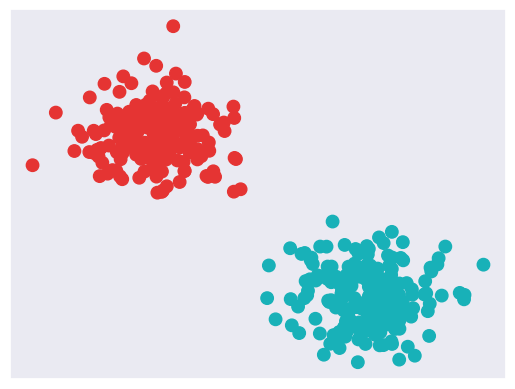

In [11]:
# Draw the starting data

dot_clr_0 = '#E53433' # red
dot_clr_1 = '#18B1B8'  # blue
dot_cmap = LinearSegmentedColormap.from_list('dot_map', [dot_clr_0, dot_clr_1], N=100)
img_cmap = 'cool'
X_blobs, y_blobs = make_blobs(n_samples=400, n_features=2, centers=2, random_state=42, cluster_std=1.25)
show_Xy(X_blobs, y_blobs, 'NB-start-blobs')

save_figure (stub) – no file will be saved.


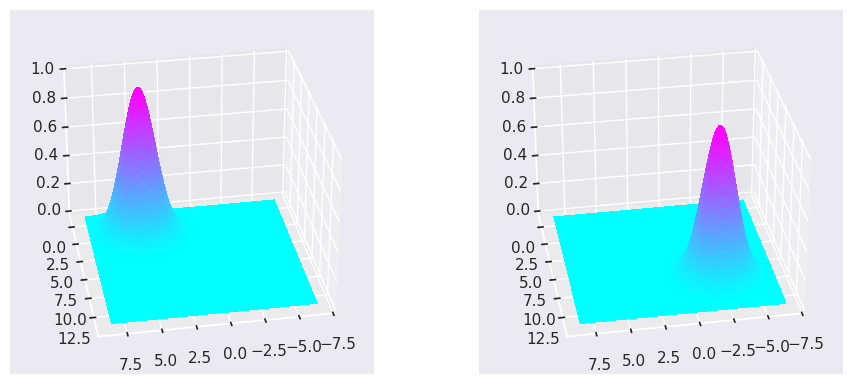

In [12]:
# Fit blobs to the data using naive Bayes, and show them

nb_blobs = GaussianNB()
nb_blobs.fit(X_blobs, y_blobs)
show_3D_gaussians(X_blobs, y_blobs, 'NB-gaussians-3D-blobs')

save_figure (stub) – no file will be saved.


/tmp/ipykernel_319/995626911.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X0[:,0], X0[:,1], facecolor='none', edgecolor=dot_clr_0, lw=0.5, s=50, cmap=dot_cmap, zorder=10)
/tmp/ipykernel_319/995626911.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X1[:,0], X1[:,1], facecolor='none', edgecolor=dot_clr_1, lw=0.5, s=50, cmap=dot_cmap, zorder=10)


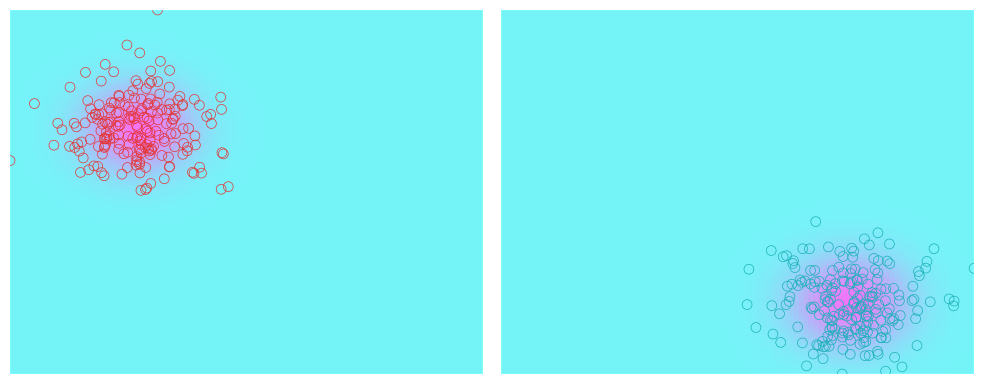

In [13]:
# Show the points over the Gaussian blobs

show_Gauss_and_dots(X_blobs, y_blobs, 'NB-dots-blobs')

save_figure (stub) – no file will be saved.


/tmp/ipykernel_319/2710159752.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_test[mask,0], X_test[mask,1], facecolor='none', edgecolor=dot_clr_0, lw=1, s=50, cmap=dot_cmap, zorder=10)
/tmp/ipykernel_319/2710159752.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_test[mask,0], X_test[mask,1], facecolor='none', edgecolor=dot_clr_1, lw=1, s=50, cmap=dot_cmap, zorder=10)


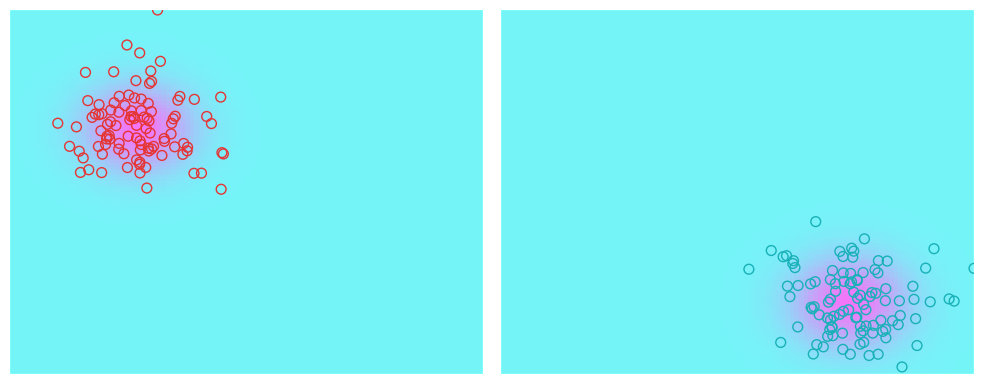

In [14]:
# Show how naive Bayes predicts the test data

show_predictions(X_blobs, y_blobs, 'NB-Blob-predictions')

save_figure (stub) – no file will be saved.


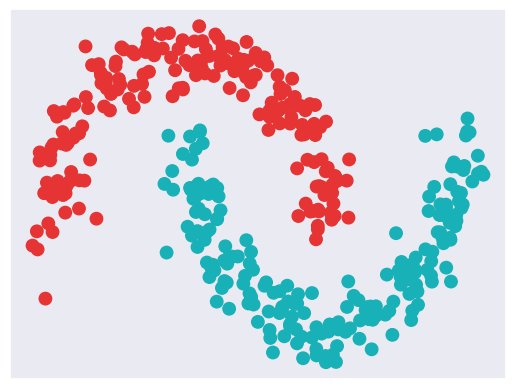

In [15]:
# Make and show the two-moons data

X_moons, y_moons = make_moons(n_samples=400, shuffle=True, noise=0.1, random_state=42)
show_Xy(X_moons, y_moons, 'NB-start-moons')

save_figure (stub) – no file will be saved.


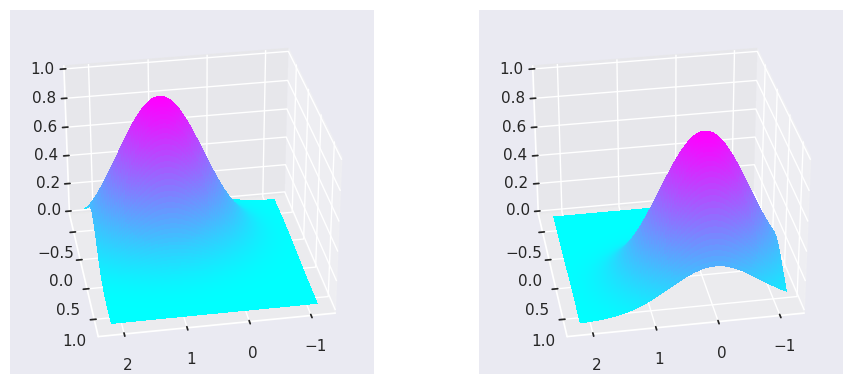

In [16]:
# Run naive Bayes on the two-moons data and show the blobs

nb_gaussian = GaussianNB()
nb_gaussian.fit(X_moons, y_moons)
show_3D_gaussians(X_moons, y_moons, 'NB-gaussians-3D-moons')

save_figure (stub) – no file will be saved.


/tmp/ipykernel_319/995626911.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X0[:,0], X0[:,1], facecolor='none', edgecolor=dot_clr_0, lw=0.5, s=50, cmap=dot_cmap, zorder=10)
/tmp/ipykernel_319/995626911.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X1[:,0], X1[:,1], facecolor='none', edgecolor=dot_clr_1, lw=0.5, s=50, cmap=dot_cmap, zorder=10)


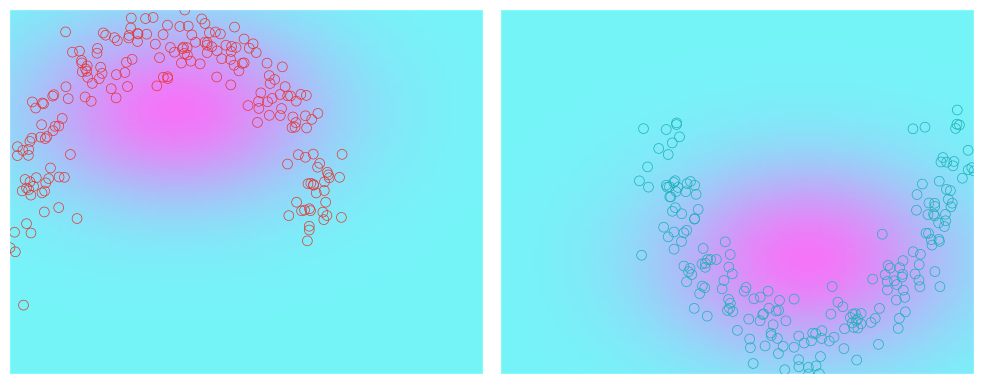

In [17]:
# Show the data and blobs

show_Gauss_and_dots(X_moons, y_moons, 'NB-dots-moons')

save_figure (stub) – no file will be saved.


/tmp/ipykernel_319/2710159752.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_test[mask,0], X_test[mask,1], facecolor='none', edgecolor=dot_clr_0, lw=1, s=50, cmap=dot_cmap, zorder=10)
/tmp/ipykernel_319/2710159752.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_test[mask,0], X_test[mask,1], facecolor='none', edgecolor=dot_clr_1, lw=1, s=50, cmap=dot_cmap, zorder=10)


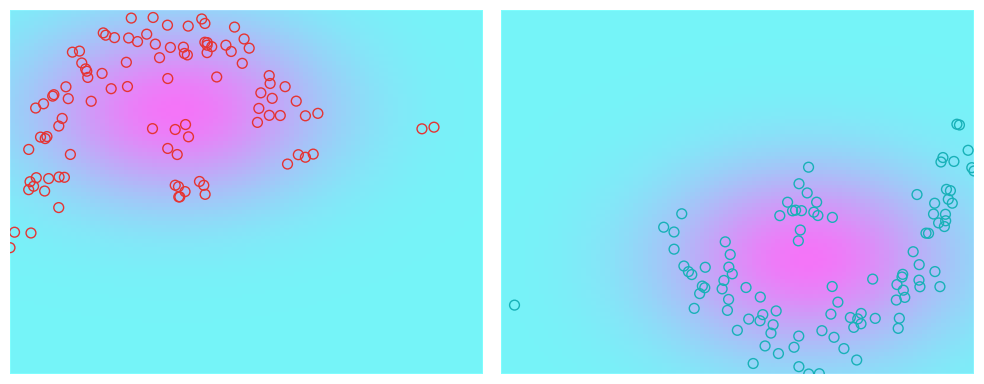

In [18]:
# Show the predictions for this test data

show_predictions(X_moons, y_moons, 'NB-Moon-predictions')